# Computation of Greeks using the Malliavin Calculus

This section offers a brief introduction to Malliavin calculus and its applications to mathematical finance, in particular to computation of the Greeks by the Monte Carlo method. The simplest way to compute sensitivities of an option by Monte Carlo method consists in approximating the derivatives by incremental ratios obtained by simulating the payoffs corresponding to close values of the underlying asset, the so called finite differences method.
If the payoff function is *not regular* (for example, in the case of a digital option with strike $K$ and payoff function $\mathbb{1}_{[K,+\infty[}$) this technique is not efficient since the incremental ratio has typically a very lange variance. The problem can be solved by integrating by parts and differentiating the density function of the underlying asset, provided it is sufficiently regular: if the underlying asset follows a geometric Brownian motion, this is possible since the explicit expression of the density is known. In a more general setting, the Malliavin calculus allows obtaining explicit integration-by-parts formulas even if the density of the underlying asset is not known and so it provides an effective tool to approximate the Greeks numerically.

The applications of Malliavin calculus to mathematical finance are relatively recent: Malliavin's result initially attracted great interest in view of the proof and extension of Hörmander's hypoellipticity theorem. From a theoretical point of view, a remarkable financial application is the Clark-Ocon formula, that improves the martingale representation theorem and allows expressing the hedging strategy of an option in terms of the stochastic derivative of its price. We also recall that Malliavin calculus was recently used to approximate numerically the price of American options by the Monte Carlo method.

We give some basic ideas of Malliavin calculus by analyzing several examples of the applications to the computation of the Greeks. We confine ourselves to the one-dimensional case, choosing simplicity instead of generality.

## Integration by parts and computation of the Greeks

In this part we prove a stochastic integration-by-parts formula and by means of some remarkable examples, we illustrate its application to the computation of the Greeks by the Monte Carlo method. As we have already said in the introduction, these techniques can be effective also when *poor regularity properties* are assumed on the payoff function $F$, i.e. just where the direct application of the Monte Carlo method gives unsatisfactory results, even if the underlying asset follows a simple geometric Brownian motion.

The stochastic integration by parts allows removing the derivatives of the payoff function, thus improving the numerical approximation: more precisely, let us suppose thet we want to determine $\partial_\alpha\mathbb{E}[F(S_T)Y]$ where $S_T$ denotes the final price of the underlying asset depending on a parameter $\alpha$ and $Y$ is some random variable (e.g. a discont factor). The idea is to try to express $\partial_\alpha F(S_T)Y$ in the form
$$
\int_0^T D_s F(S_T)YU_s \,ds,
$$
for some adapted integrable process $U$. By using the duality relation, formally we obtain
$$
\partial_\alpha\mathbb{E}[F(S_T)Y]=\mathbb{E}[F(S_T)D^*(YU)],
$$
that, as we shall see in the following examples, can be used to get a good numerical approximation. Since we want to show how to apply a technique rather than dwelling on the mathematical detail, the presentation will be somewhat informal.

**Theorem (Stochastic integration by parts)**

Let $F\in C_b^1$ and let $X\in\mathbb{D}^{1,2}$. Then the following integration by parts holds:
$$
\mathbb{E}[F'(X)Y]=\mathbb{E}\left[F(X)\int_0^T\frac{u_t Y}{\int_0^T u_s D_s X ds}\diamond\,dW_t\right],
$$
for every random variable $Y$ and for every stochastic process $u$ for which it is well-defined.

**Proof (sketch)**

By the chain rule we have
$$
D_t F(X) = F'(X)D_tX.
$$
Multiplying by $u_t Y$ and integrating from $0$ to $T$ we get
$$
\int_0^T u_t Y D_t F(X)\,dt = F'(X)Y \int_0^T u_t D_t X\,dt,
$$
whence, provided that
$$
\frac{1}{\int_0^T u_t D_t X\,dt}
$$
has good integrability properties, we have
$$
F'(X)Y = \int_0^T D_t F(X)\frac{u_t Y}{\int_0^T u_s D_s X\,ds}\,dt.
$$
Taking the mean and by the duality relation we have
$$
\mathbb{E}[F'(X)Y] = \mathbb{E}\left[\int_0^T D_t F(X)\frac{u_t Y}{\int_0^T u_s D_s X\,ds}\,dt\right]=\mathbb{E}\left[F(X)\int_0^T\frac{u_t Y}{\int_0^T u_s D_s X\,ds}\diamond \,dW_t\right].
$$
<div style="text-align: right;">$\square\qquad$</div>

The regularity assumptions on the function $F$ can be greatly weakened: by using a standard regularization procedure, it is possible to prove the validity of the integration-by-parts formula for weakly differentiable (or even differentiable in a distributional sense) functions.

The process $u$ in the formula can be often chosen in a suitable way in order to simplify the expression of the integral on the right-hand side. If $u=1$ and $Y=\partial_\alpha X$, the integration-by-parts formula becomes
$$
\mathbb{E}[\partial_\alpha F(X)]=\mathbb{E}\left[F(X)\int_0^T\frac{\partial_\alpha X}{\int_0^T D_s X\,ds}\diamond\,dW_t\right],
$$
where $\diamond$ denotes the Skorohod integral and the term $\int_0^T\frac{\partial_\alpha X}{\int_0^T D_s X\,ds}\diamond\,dW_t$ is also called *Malliavin weight* as only depends on the underlying dynamics and not on the payoff function.

# Black-Scholes dynamics

In the following examples we consider the Black-Scholes dynamics for the underlying asset for an option under the EMM. Let the initial stock price $S_0=x$ and we apply the integration-by-parts formula with $X=S_T$ where
$$
S_T=x \exp{\left(\left(r-\frac{\sigma^2}{2}\right)T+\sigma W_T\right)},
$$
with the following parameters

In [11]:
x = 100.0
r = 0.05
sigma = 0.30
T = 1.0

In the Black-Scholes model, the value of an option is a function of several variables: the price of the underlying asset, the time to maturity, and the parameters of the model (specifically, the volatility $\sigma$ and the risk-free short-term rate $r$). From a practical perspective, it is essential to evaluate the sensitivity of an option (or a portfolio) with respect to variations in these factors. The natural sensitivity indicators are the partial derivatives of the option value with respect to the corresponding risk factors. A Greek letter is conventionally associated with each partial derivative; for this reason, these sensitivity measures are usually referred to as the Greeks.

Let $F(S_T)$ be the payoff function of the option at maturity $T$. Under the risk-neutral probability measure $\mathbb{Q}$, the value of the option at time $t=0$, given an initial underlying price $S_0 = x$, is defined as:
$$
V(0, x) = e^{-rT} \mathbb{E}^{\mathbb{Q}}\left[ F(S_T) \mid S_0 = x \right]
$$

The Greeks are then defined as the following partial derivatives of the pricing function $V$:
\begin{align*}
\Delta &= \partial_x V(0,x) = \partial_x \left( e^{-rT}\mathbb{E}^{\mathbb{Q}}\left[F(S_T) \mid S_0=x\right] \right), & (\text{Delta}),\\
\Gamma &= \partial_{xx} V(0,x) = \partial_{xx} \left( e^{-rT}\mathbb{E}^{\mathbb{Q}}\left[F(S_T) \mid S_0=x\right] \right), & (\text{Gamma}),\\
\mathcal{V} &= \partial_\sigma V(0,x) = \partial_\sigma \left( e^{-rT}\mathbb{E}^{\mathbb{Q}}\left[F(S_T) \mid S_0=x\right] \right), & (\text{Vega}),\\
\rho &= \partial_r V(0,x) = \partial_r \left( e^{-rT}\mathbb{E}^{\mathbb{Q}}\left[F(S_T) \mid S_0=x\right] \right), & (\text{Rho}),\\
\Theta &= -\partial_T V(0,x) = \partial_t V(t,x)\Big|_{t=0}, & (\text{Theta}).
\end{align*}

# Delta computation

### Finite difference Delta

Finite Differences approach can be used as a benchmark in all cases we want to study. The finite difference method (central difference scheme) for the Delta has the form
$$
\Delta \approx e^{-rT}\frac{\mathbb{E}\left[F(S_T)|S_0=x+\varepsilon\right]-\mathbb{E}\left[F(S_T)|S_0=x-\varepsilon\right]}{2\varepsilon},
$$
with sufficiently small $\varepsilon$.

In [15]:
def call_delta_fd(payoff, r, sigma, x, T, N, epsilon):

    brownian_sample = stats.norm.rvs(size=N) * np.sqrt(T)
    gbm_sample_up= (x + epsilon)*np.exp((r - 0.5*sigma**2)*T + sigma*brownian_sample)
    gbm_sample_down = (x - epsilon)*np.exp((r - 0.5*sigma**2)*T + sigma*brownian_sample)
    constant = np.exp(-r*T)
    
    payoff_plus = payoff(gbm_sample_up)
    payoff_minus = payoff(gbm_sample_down)
    
    deltas = []
    sizes = range(100, N+1, 100)
    
    for k in sizes:
        
        fd = np.mean((payoff_plus[:k] - payoff_minus[:k])/(2.0*epsilon))
        delta = constant*fd
        deltas.append(delta)
        
    return sizes, deltas

### Malliavin Delta

We observe that $D_s S_T=\sigma S_T$ and $\partial_x S_T=\frac{S_T}{x}$. Then, we have the following expression for the Black-Scholes Delta
\begin{align*}
\Delta &= e^{-rT}\partial_x\mathbb{E}[F(S_T)], \\
&= e^{-rT}\mathbb{E}\left[F(S_T)\int_0^T \frac{\partial_x S_T}{\int_0^T D_s S_T \,ds}\diamond\,dW_t\right], \\
&= e^{-rT}\mathbb{E}\left[F(S_T)\int_0^T \frac{1}{\sigma T x}\,dW_t\right], \\
&= \frac{e^{-rT}}{\sigma T x}\mathbb{E}\left[F(S_T)W_T\right].
\end{align*}

In [17]:
def call_delta_malliavin(payoff, r, sigma, x, T, N):

    brownian_sample = stats.norm.rvs(size=N) * np.sqrt(T)
    gbm_sample = x*np.exp((r - 0.5*sigma**2)*T + sigma*brownian_sample)
    constant = np.exp(-r*T)/(sigma*T*x)

    deltas = []
    sizes = range(100, N+1, 100)
    for k in sizes:
        
        mc_estimator = np.mean(payoff(gbm_sample[:k])*brownian_sample[:k])
        delta = constant*mc_estimator
        deltas.append(delta)
    
    return sizes, deltas

## European Call option

### Analytical Delta

Under the Black-Scholes model, the exact value of the Delta of a call option is
$$
\Delta = \Phi(d_1),
$$
where $\Phi(x)$ is the cumulative distribution function (CDF) of the standard normal distribution and
$$
d_1=\frac{\log \left( \frac{x}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}.
$$

In [20]:
def call_delta_bs(x, K, T, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(T)
        KrT = np.exp(-r * T) * K
        d1 = np.log(x / KrT) / s + s / 2
        delta = stats.norm.cdf(d1)
     
    return delta

### Computation comparison

In [22]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm

N = 100000        # number of Monte Carlo simulations
K = 100.0         # strike
epsilon = 0.1   

In [23]:
# payoff function

def payoff(x, K, kind):
    if kind == "call":
        return np.maximum(x - K, 0)
    elif kind == "put":
        return np.maximum(K - x, 0)
    elif kind == "digital call":
        return np.where(x > K, 1, 0)
    elif kind == "digital put":
        return np.where(x < K, 1, 0)
    elif kind == "asian call":
        return np.maximum(np.mean(x) - K, 0)
    elif kind == "asian put":
        return np.maximum(K - np.mean(x), 0)
    else:
        return 0

Delta of European Call = 0.624252  


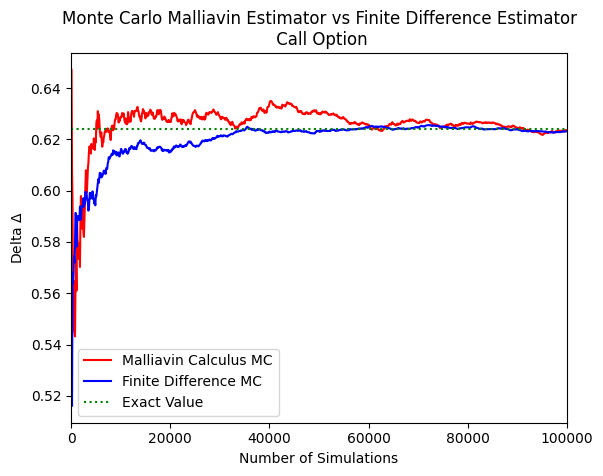

In [24]:
sizes, fd_deltas = call_delta_fd(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon)
sizes, malliavin_deltas = call_delta_malliavin(lambda x: payoff(x, K=K, kind="call"), r=r, sigma=sigma, x=x, T=T, N=N)
call_delta = call_delta_bs(x=x, K=K, T=T, r=r, sigma=sigma)

print(f"Delta of European Call = {call_delta:<10.6f}")

plt.plot(sizes, malliavin_deltas, color="red", label="Malliavin Calculus MC")
plt.plot(sizes, fd_deltas, color="blue", label="Finite Difference MC")
plt.hlines(call_delta, 0, sizes[-1], color="green", linestyle=":", label="Exact Value")
plt.xlim([0.0, sizes[-1]])
plt.ylabel("Delta $\Delta$")
plt.xlabel("Number of Simulations")
plt.title("Monte Carlo Malliavin Estimator vs Finite Difference Estimator\n Call Option")
plt.legend(loc='best')
plt.show()

## Digital Call option

### Analytical Delta

Under the Black-Scholes model, the exact value of the Delta of a digital call option is
$$
\Delta = \frac{e^{-rT}\phi(d_2)}{x\sigma\sqrt{T}},
$$
where $\phi(x)$ is the probability density function (PDF) of the standard normal distribution and
$$
d_2=\frac{\log \left( \frac{x}{K} \right) + \left( r - \frac{\sigma^2}{2} \right) T}{\sigma \sqrt{T}}.
$$

In [27]:
def digital_call_delta_bs(x, K, T, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(T)
        KrT = np.exp(-r * T) * K
        d2 = np.log(x / KrT) / s - s / 2
        delta = np.exp(-r*T)*stats.norm.pdf(d2) / (x * s)
     
    return delta

### Computation comparison

Delta of Digital Call = 0.012648  


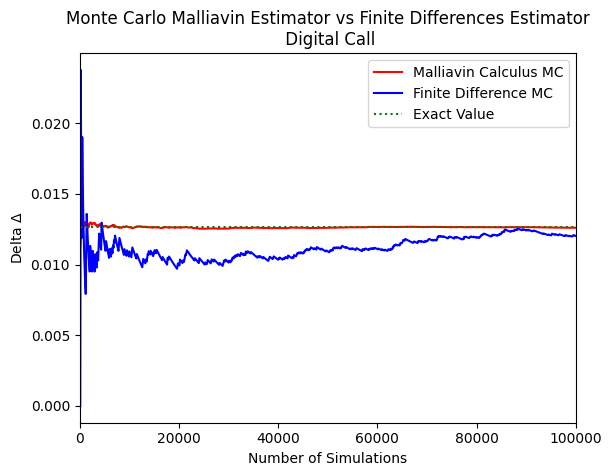

In [29]:
sizes, fd_deltas = call_delta_fd(lambda x: payoff(x, K=K, kind="digital call"), r=r, sigma=sigma, x=x, T=T, N=N, epsilon=epsilon)
sizes, malliavin_deltas = call_delta_malliavin(lambda x: payoff(x, K=K, kind="digital call"), r=r, sigma=sigma, x=x, T=T, N=N)
digital_call_delta = digital_call_delta_bs(x=x, K=K, T=T, r=r, sigma=sigma)

print(f"Delta of Digital Call = {digital_call_delta:<10.6f}")

plt.plot(sizes, malliavin_deltas, color="red", label="Malliavin Calculus MC")
plt.plot(sizes, fd_deltas, color="blue", label="Finite Difference MC")
plt.hlines(digital_call_delta, 0, sizes[-1], color="green", linestyle=":", label="Exact Value")
plt.xlim([0.0, sizes[-1]])
plt.ylabel("Delta $\Delta$")
plt.xlabel("Number of Simulations")
plt.title("Monte Carlo Malliavin Estimator vs Finite Differences Estimator\n Digital Call")
plt.legend(loc='best')
plt.show()

As can be seen from the plot, the Malliavin estimator is much more efficient than the finite difference method, as expected. The reason is that the former has lower simulation variance and converges faster.